# A Practical Manual for the Engineering DSL

This is a reference for the source-rewriting DSL installed in `utils/`. It assumes you know Python and are meeting [`forallpeople`](https://github.com/connorferster/forallpeople) — the SI-units library this builds on — for the first time.

**What the DSL gives you**

* SI units that flow through calculations, with automatic dimensional analysis.
* Significant-figure tracking so your results don't claim more precision than your inputs supplied.
* Engineering notation that looks like engineering notation: `R := 4.7 kΩ`, `5 ∠ 30°`, `Z1 ‖ Z2`, `⌈log₁₀(N)⌉`.
* A bank of physical constants ready to multiply through formulas.

**How it works (one paragraph)**

Source-level rewriting at import time. When Python tries to load a file (or run a Jupyter cell after the hook is installed), the source string is intercepted and rewritten. `R := 4.7 kΩ` becomes `R = _S(4.7, 2) * kΩ` — the literal wrapped with its significant-figure count, times the unit — *before* the parser sees it. The result is plain Python that runs against `forallpeople`-aware values. Everything in this notebook is just well-disguised Python — no compiler, no runtime magic beyond ordinary operator overloading.

**A note on naming throughout this manual.** Engineering math overloads single letters: `V` is volts but is also a voltage; `R` is a resistor but also the gas constant; `I` is current, `F` is force or farad. To avoid confusion, examples in this manual use slightly more verbose variable names (`V_supply`, `R_load`, `I_in`) so the *unit* names — `V`, `Ω`, `A`, `F` — never get shadowed. Your own code can be more terse if you keep the conflicts in mind.


## 1. Setup

Import order matters. The source-transform hook must be installed *before* any code containing DSL syntax is parsed. The pattern below is the safe one:

1. Bring in `forallpeople` and activate its environment, so `V`, `Ω`, `m`, etc. become module-level names.
2. Import the DSL module (this loads it un-transformed, which is correct — the helpers themselves are written in plain Python).
3. Install the hook with `dsl.add_hook()`.
4. Now do `from utils.circuit_dsl import *` and `from utils.calc_symbols import *`. Anything imported *after* the hook will be source-transformed.

In a Jupyter session, the hook also registers an input transformer for cells, so cell content gets rewritten the same way module imports do.

In [1]:
from utils.Engineer import *

[Engineer] could not launch palette: [WinError 2] The system cannot find the file specified


## 2. Units (a `forallpeople` primer)

`forallpeople` represents physical quantities as `Physical` objects. A `Physical` carries a numeric value, dimensions (a 7-tuple of exponents over the SI base units), and a preferred display unit. When you multiply or divide them, dimensions combine; when you add or subtract them, the dimensions must match or you get an error.

After `si.environment('default', top_level=True)`, the common SI units are available as bare names: `m`, `kg`, `s`, `A`, `K`, `mol`, `V`, `Ω`, `W`, `F`, `H`, `Hz`, `J`, `N`, `Pa`, `C`, plus prefixed conveniences like `mV`, `kΩ`, `μF`, `nH`, `MHz`.

In [2]:
# A bare numeric times a unit produces a Physical:
V_supply := 5 V
I_load := 25 mA          # prefix-bearing unit name
R_load := 220 Ω
pp('V_supply=',V_supply,', I_load=',I_load,', R_load=', R_load)

<IPython.core.display.Math object>

In [3]:
# Math composes; dimensions follow:
P_load := I_load × V_supply        # power = current × voltage  →  watts
pp('P_load =', P_load)

V_drop := I_load × R_load          # voltage = current × resistance  →  volts
pp('V_drop =', V_drop)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
# Add two quantities of the same dimension — fine.
print(220 Ω + 4.7 kΩ)

# Add quantities of different dimensions — error.
try:
    bad := 5V + 1A
except Exception as e:
    print(type(e).__name__, '→', e)

4900 Ω
ValueError → Cannot add between 5.000 V and 1.000 A: .dimensions attributes are incompatible (not equal)


**Display vs internal value.** A `Physical` always stores its value in SI base units; `4.7 kΩ` is internally `4700.0`. A literal remembers the unit it was *written* in and displays in it — `22735 mm` prints `22735 mm`, not `22.735 m` — and that written unit follows the value through arithmetic while the dimensions still match it (the left operand's unit wins for `+`/`-`, so `220 Ω + 4.7 kΩ` prints `4900 Ω`). A computed result that no longer matches any written unit (`12 V / 3 A`) falls back to forallpeople's auto-chosen SI prefix. Math operations don't care about the display; use `▸` to show any value in a unit of your choosing.

## 3. Assignment operators: `:=` and `←`

The DSL repurposes `=` as **equality test** and uses `:=` (or its glyph form `←`) for **assignment**. The motivation is that handwritten engineering notes use `=` ambiguously — it's both "I'm setting this" and "this equals that". Splitting the two glyphs disambiguates.

| You write | Python sees |
|---|---|
| `R := 220 Ω` | `R = 220 * Ω` |
| `R ← 220 Ω` | `R = 220 * Ω` |
| `R = 220 Ω` | `R == 220 * Ω` |

So when you see `R = 220 Ω` in a cell, that's a *boolean expression*, not an assignment.

In [5]:
R_test := 220 Ω        # assign
pv(R_test)

if R_test = 220 Ω:     # `=` at top level becomes equality
    pp('R_test equals 220 Ω')
else:
    pp('No match')

<IPython.core.display.Math object>

R_test equals 220 Ω


The `:=` rewrite is conservative. Walrus expressions inside parentheses (`if (x := f()) > 0:`) still work as ordinary Python because the LHS isn't a bare assignable target.

## 4. Math notation that just works

### Implicit multiplication
Adjacent tokens with whitespace or specific Unicode glyphs between them get a `*` inserted. So `2π`, `5 V`, `(a+b)(c-d)` all multiply.

In [6]:
x := 2π·50        # 2π·50 — angular frequency for 50 Hz
pv(x)

y := 3 (4 + 5)      # juxtaposition multiplies
pv(y)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Superscripts and √
`x²` and `x³` rewrite to `x**2` and `x**3` etc.. `√x` becomes `sqrt(x)`. `³√x` also works, as do the
precomposed `∛x` and `∜x`. A `⁻¹` on a trig name is the *inverse function*: `sin⁻¹(0.5)` is `asin(0.5)`,
not `sin` raised to the power −1.


In [7]:
r := 1.5 m
A_circle := π r²            # circle area
V_sphere := (4/3) π r³      # sphere volume
pv(A_circle, V_sphere)

pn('√16=',√16)
pp('√16=',√16)
pp('√(2 + 7)=',√(2 + 7))
pp('r⁸=',r⁸)
pp('⁵√x=',⁵√x)
pp('∛27=', ∛27, ', ∜16=', ∜16, ', sin⁻¹(0.5)=', sin⁻¹(0.5))
k := 3
pp('2ᵏ=',2ᵏ,',ᵏ√(x)=', ᵏ√x)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

√16= 4.00000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Subscript indexing
`xs₂` is `xs[2]`. Negative subscripts `xs₋₁` work too. Note that this means subscripts are **not** for naming — `R₁` is `R[1]`, not a variable named "R subscript 1". For named subscripts use ASCII (`R1`) or an underscore (`R_1`).

In [8]:
samples := [10, 20, 30, 40, 50]
pp(samples₂, samples₋₁)
pv(samples)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Greek letters as identifiers
A wide selection of Greek letters parse as identifier characters: lowercase α β γ δ ε ζ η θ ι κ λ μ ν ξ ο ρ ς σ τ υ φ χ ψ ω, plus uppercase Φ Θ Λ Ψ Γ Π Σ Ω, plus π and ε. Compound names like `ε_0`, `μ_0`, `ω_c` work — Python 3 accepts Unicode identifiers natively, the DSL's job is just to recognise them in its own rewrites.

In [9]:
ω := 2π * 50 Hz
ν := 5e14 Hz
λ_yellow := c / ν
pp(ω, λ_yellow)

<IPython.core.display.Math object>

### Math glyphs in `normalize_source`
A handful of Unicode math glyphs translate to their ASCII operator equivalents before any other rewrite runs:

| Glyph | Meaning |
|---|---|
| `·` `⋅` `×` | `*` |
| `÷` | `/` |
| `−` | `-` (Unicode minus to ASCII hyphen-minus) |
| `≠` `≤` `≥` | `!=` `<=` `>=` |
| `½` `⅓` `¼` ... | `(1/2)` `(1/3)` `(1/4)` ... |


In [10]:
res := [2 · 3, 2 × 3, 6 ÷ 2, ½ + ⅓] 
pv(res)

<IPython.core.display.Math object>

## 5. Engineering operators: `‖`, `±`, `≈`

### Parallel: `‖`
`a ‖ b` rewrites to `parallel(a, b)`, which is `1/(1/a + 1/b)`. Useful for parallel resistors, parallel capacitances on inductors, parallel impedances, parallel springs (mechanical analogue).

The rewriter recognises atomic operands — a bare identifier, a number, or a parenthesised expression. **Wrap multi-token operands in parentheses**: `(R1*2) ‖ (R2*2)` is fine; `R1*2 ‖ R2*2` confuses the rewriter because `2 ‖ R2` would match before the multiplications resolve.

In [11]:
R1 := 220 Ω
R2 := 4.7 kΩ
R_eq := R1 ‖ R2
pv(R_eq)

# For chains of three or more, nest explicitly with parens:
R_a := 100. Ω
R_b := 100. Ω
R_c := 100. Ω
R_p := R_a ‖ R_b ‖ R_c
pv(R_p)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Plus-minus: `±` — and its printout `‥`
`a ± b` produces a `Range` value bracketing `[a-b, a+b]`. Useful for tolerances and uncertainties.

A tolerance written as a percentage (or permille) is **relative to the centre**, the way a
component tolerance is read: `100 Ω ± 5%` is `(95 Ω ‥ 105 Ω)`, `4.7 kΩ ± 1%` is
`(4.653 kΩ ‥ 4.747 kΩ)`. Only a literal `%` / `‰` on the tolerance triggers this — once the
ratio has been through arithmetic it is an ordinary number again, so `100 ± (1 + 25%)` is the
absolute interval `(98.75 ‥ 101.25)`. Anything else after `±` is an absolute half-width.

Beyond `+ − × ÷` and powers, an interval supports membership (`102 Ω in R`, also for a
sub-interval), `|R|` / `abs()` (folding at zero), `R.center`, `R.tol` (half-width) and `R.width`,
`b ** R`, and the transcendental functions: `sin(θ ± δ)`, `exp`, `ln`, `√`, `log₁₀` … return the
*image* of the interval, with interior maxima and minima accounted for (`sin(1.5 ± 0.2)` tops out
at exactly 1). `tan` over an interval that contains a pole is an error, not a number.

An interval prints as its two ends. To read it as centre and tolerance instead, tag it for
display: `R ▸ plusminus` gives `100 Ω ± 5 Ω`, `R ▸ percent` gives `100 Ω ± 5.00%` and
`R ▸ permille` the same in ‰. Like every `▸` tag it is display-only and disappears under arithmetic.

A `Range` prints as `(low ‥ high)` with the two-dot leader `‥` (U+2025), and that
printout is itself valid input: `(95 Ω ‥ 105 Ω)` rebuilds the same interval, so a
result can be pasted straight back into a later cell. Don't confuse it with the
two-ASCII-dot `..`, which *enumerates* every step between the ends —
`3 ‥ 7` is the single interval `[3, 7]`, `[3..7]` is the list `[3, 4, 5, 6, 7]`.
`..` also accepts unit-carrying ends and steps in the unit they were written in:
`[-55 °C..125 °C]` is the same array as `[-55..125] °C`, `[1 kΩ..5 kΩ]` steps in kΩ.


In [12]:
# A 100 Ω ±5 Ω resistor:
R_tol := 100 ± 5 Ω
pv(R_tol, R_tol.low, R_tol.high)
# The same part written the way the datasheet does — a % tolerance is relative:
R_pct := 100 Ω ± 5%
pv(R_pct)
print(102 Ω in R_pct, 110 Ω in R_pct)
pp(R_pct.width, |−3 Ω ± 5 Ω|)
θ := 1.5 ± 0.2
pp(sin(θ), exp(θ))                  # image of the interval — sin peaks at π/2 inside
pp(R_pct ▸ plusminus, R_pct ▸ percent)
# The printed form is valid input — same interval, written from its ends:
R_same := (95 Ω ‥ 105 Ω)
pv(R_same)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

True False


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100 Ω ± 5 Ω 100 Ω ± 5.00%


<IPython.core.display.Math object>

### Approximately equal: `≈`
`a ≈ b` rewrites to `approx(a, b)` and returns a bool. Default tolerance is tight (1 ppb relative); pass keyword args for looser comparisons.

`≈` has the precedence of a comparison, like `==` and `≤`: each operand extends to the nearest
comma, bracket, keyword or end of line, so `1 + 1 ≈ 2` compares the *sum* with 2, `√2 · √2 ≈ 2`
is `True`, and `x ≈ 3 and y ≈ 4` does what it says. Chains associate left, `a ≈ b ≈ c` being
`(a ≈ b) ≈ c` — rarely what you want, so compare pairwise.

In [13]:
# floating-point gotcha:
print(0.1 + 0.2 == 0.3)        # False — surprises some people
print(0.1 + 0.2 ≈ 0.3)         # True — tolerant compare (the whole sum is the LHS)
print(√2 · √2 ≈ 2, 2·3 ≈ 7)   # True False

# Explicit tolerance via the function form:
print(approx(1.000, 1.005, rtol=1e-2))

False
True
True False
True


## 6. Engineering component values

Write component values the way they print on a schematic: a numeric literal followed by a prefixed unit. Note that RKM-style component codes (`4k7`, `100n`, `2R2`) are *not* special notation — a digit run followed by letters reads as implicit multiplication, so `4k7` is `4*k7`.

In [14]:
print(4.7 kΩ, 2.2 Ω, 47 Ω, 1.5 MHz, 100 nF, 4.7 µF, 1.5 µH)

4.7 kΩ 2.2 Ω 47 Ω 1.5 MHz 100 nF 4.7 μF 1.5 μH


### In assignments
The value–unit pair binds tighter than `*` and `/`, and the unit carries through all further arithmetic:


In [15]:
R_filt := 4.7 kΩ
C_filt := 100 nF
L_choke := 1.5 µH
f_lo   := 1.5 MHz
pv(R_filt, C_filt, L_choke, f_lo)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### What it won't touch
Unit binding only fires on a numeric literal followed by whitespace and a unit name, so it won't eat ordinary identifiers (`R1`, `R_in`), scientific literals (`1e-3`), or PEP-515 numbers (`1_000`).

In [16]:
R_in := 220 Ω             # R_in the variable, not "R-followed-by-in"
pv(R_in)
pp(1e-3, 1_000)        # untouched

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 7. Angles and phasors

### Degrees: `°`
A trailing `°` on a number, identifier, or parenthesised expression rewrites to a multiplication by `π/180`. The trig functions expect radians, so `cos(30°)` "just works" because `30°` is already in radians by the time `cos` sees it. Angle *names* exist too — `rad`, `sr` (the exact number 1, since `forallpeople` has no angle dimension), `deg`, `mrad`, `arcmin`, `arcsec`, `rev`/`turn`, `gon` — so `sin(30 deg)` is `sin(30°)`, and an angle reads back in degrees with `▸ deg`: `asin(0.5) ▸ deg` is `30 deg`. Rotational speed is a *frequency*: `3000 rpm ▸ Hz` is `50 Hz`, `50 Hz ▸ rpm` is `3000 rpm`, and the angular velocity is `ω := 2π · n` as always (see the gotcha on the written-unit tag in §26).

`°C` and `℃` (the precomposed degree-Celsius glyph) are handled separately — they normalise to `degC` early in the pipeline, before the angle-degree rule runs. So you can mix them freely.

**`°C`, `°F`, `°R` are real offset units.** A temperature literal applies the scale's offset: `22 °C` becomes `295.15 K`, `72 °F` becomes `295.37 K`, `491.67 °R` becomes `273.15 K`. The value is a genuine kelvin `Physical` and carries its dimension correctly through any calculation. Internally `22 °C` is rewritten to `from_degC(22)` — the offset is part of the literal's meaning.

Keep the **absolute** forms (`°C` `°F` `°R` — a point on the scale) distinct from the **delta** forms (`ΔC` `ΔF` `ΔK` — a temperature *difference*, no offset). `20 °C + 5 ΔC` is `25 °C` (a point plus a difference); `100 °C - 20 °C` is an 80 K difference (two points subtracted). Adding two absolute temperatures — `20 °C + 5 °C` — is physically meaningless and the toolkit does not stop you, so don't.

In [17]:
pp(cos(30°), sin(45°), tan(60°))     # exact angles → exact results
pp(cos(30.0°), sin(45.0°))           # measured angles → numbers, 3 sf


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Trig, hyperbolic and `exp`
`sin cos tan asin acos atan atan2 sinh cosh tanh asinh acosh atanh exp` are the toolkit's own
wrappers, not raw sympy or `math`. They pick the right behaviour from the argument:

* a **number** (any literal, `Sig`) → computed with `math`, and the result keeps the input's
  significant figures: `sin(0.500)` is 3 sf, `exp(1.0)` prints `2.7` (not the symbol `E`);
* an **exact angle** such as `30°` or `π/4` (integer literal times `π`) → sympy's closed form,
  `sin(30°)` is `1/2` and `sin(60°)` is `√3/2`; a measured `60.0°` collapses to `0.500`;
* a **symbolic** expression → stays symbolic, so `diff(sin(x), x)` and plotting sweeps work;
* a **dimensioned** quantity → `TypeError`. `sin(2 V)` has no meaning; divide by a reference first.

`atan2(y, x)` accepts two quantities of the same dimension — `atan2(1.0 m, 2.0 m)` is the
angle from two legs — and refuses mixed dimensions. Read an angle back in degrees with `▸ deg`.


In [18]:
pp(sin(0.500), sigfigs_of(sin(0.500)))      # 0.479, 3 sf
pp(exp(1.0), sinh(1.0), atanh(0.5))
pp(sin(60°), cos(60.0°))                    # exact vs measured
pp(atan2(1.0 m, 2.0 m) ▸ deg)               # angle from two legs, read back in degrees
symbols: x
pp(diff(sin(x)·exp(x), x))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
# °C is a real offset unit — 22 °C is 295.15 K:
T_room := 22 °C
θ      := 30°                 # an angle, unrelated — bare ° is fine
pv(T_room)               # 295.15 K
pv(θ)                     # 0.5236  (radians)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Phasors: `∠`
`a ∠ b` rewrites to `phasor(a, b)`, which returns a `complex` (the magnitude rotated by the angle). The `°` rule runs first, so `5 ∠ 30°` ends up as `phasor(5, π/6)` ≈ `4.33 + 2.5j` — and it *prints* as `5.0 ∠ 30°`, the same form you typed, so a result pastes back as input. Arithmetic returns an ordinary rectangular complex; `polar(z)` re-tags a result for polar display and `rect(z)` forces the `a+bj` form (also `z ▸ polar` / `z ▸ rect`).

**Important constraint.** `phasor()` requires *unitless* magnitudes — `forallpeople`'s `Physical` cannot multiply with `complex` (a fundamental incompatibility, not a bug). Writing `5.0 Ω ∠ 30°` raises a `TypeError` rather than silently dropping the ohms. The convention for AC analysis is therefore: keep magnitudes unitless during the phasor algebra, then attach a unit to the *real* result via `abs()` at the end.

In [20]:
V_a := 5 ∠ 0°
V_b := 5 ∠ 30°
pv(V_a)
pp('V_b=',V_b, ', |V_b| =', abs(V_b))
pp(V_a + V_b, polar(V_a + V_b), rect(V_b))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Worked example: AC voltage divider
A 230 V source at 50 Hz drives a 4.7 kΩ resistor in series with a 100 nF capacitor. What's the voltage across the capacitor?

The DSL lets the calculation read like the textbook formula. Note where the unit gets attached.

In [21]:
V_in     := 230 ∠ 0°            # source phasor (unitless)
R_div    := 4.7 kΩ/kΩ              # resistance value(unitless)
C_div    := 100 nF/nF              # capacitance value(unitless)
f := 50 Hz/Hz
ω_50hz   := 2πf                 # 50 Hz angular freq

Z_C      := 1 / (i · ω_50hz · C_div)   # capacitor impedance — complex, unitless
Z_total  := R_div + Z_C                  # series impedance

V_C_complex := V_in * Z_C / Z_total           # voltage divider, complex
V_C_mag     := abs(V_C_complex) V           # attach unit on the real magnitude (V)

pv(V_C_complex)
pp('|V_C|       =', V_C_mag)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 8. Logarithms and decibels

### Subscripted base
`log₁₀(x)` and `log₂(x)` rewrite to `log10(x)` and `log2(x)` (these are runtime helpers around `math.log10`/`math.log2`). The general subscript-as-index rule that turns `xs₁` into `xs[1]` is suppressed for `log` so `log₁₀(x)` doesn't become `log[10](x)`.

`ln(x)` is the natural log — same as `math.log(x)`, but available without an extra import.

In [22]:
pp('log₁₀(1000)=',log₁₀(1000))
pp('log₂(1024)=',log₂(1024))
pp('ln(e)=',ln(math.e))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Decibels
Two flavours of dB conversion are exposed, distinguished by whether the input is a power ratio or an amplitude/voltage ratio:

| Function | Formula | Use for |
|---|---|---|
| `to_dB_p(x)` | 10·log₁₀(x) | power ratios |
| `to_dB_v(x)` | 20·log₁₀(x) | voltage / amplitude / current ratios |
| `from_dB_p(x)` | 10^(x/10) | dB → power ratio |
| `from_dB_v(x)` | 10^(x/20) | dB → amplitude ratio |

A 100× power ratio is 20 dB. A 10× *voltage* ratio is also 20 dB (because power scales as voltage²).

In [23]:
pp('100x power   =', to_dB_p(100), 'dB')
pp('10x  voltage  =', to_dB_v(10),  'dB')

pp('20 dB ratio (voltage) =', from_dB_v(20))
pp('30 dB ratio (power)   =', from_dB_p(30))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 9. Floor and ceiling

`⌊x⌋` rewrites to `floor(x)`, `⌈x⌉` to `ceil(x)`. The brackets are unambiguous Unicode glyphs and don't collide with any other DSL operator.

In [24]:
print(⌊3.7⌋, ⌈3.2⌉)
print(⌊π⌋, ⌈π⌉)

3 4
3 4


### Worked example: how many amplifier stages?
You need 1000× total gain and your stages cap out at 4× each. How many stages?

In [25]:
gain_total      := 1000
gain_per_stage  := 4
n_stages := ⌈log₁₀(gain_total) / log₁₀(gain_per_stage)⌉
print('Need', n_stages, 'stages')

Need 5 stages


## 10. Special functions: `Γ`, `Π`, `Σ`, `σ`

### Gamma
`Γ(x)` is `math.gamma(x)`, the smooth interpolant of the factorial: `Γ(n) = (n-1)!` for positive integers, and gracefully extends to non-integer arguments. Useful for Stirling-style approximations, gamma distributions in noise analysis, n-ball volumes, and anywhere a factorial would otherwise need to be computed at a non-integer value.

Note: numeric literals carry the sf the digit form claims. `Γ(0.5)` runs with sf=1 (one significant figure), so the result displays at 1 sf. Wrap with `exact()` if you want full precision.

In [26]:
print(Γ(5))                     # 4! = 24
print(Γ(exact(0.5)))            # √π, full precision
print(Γ(exact(1.5)))            # (1/2)·√π

24.0
1.7724538509055159
0.886226925452758


### Product
`Π(iterable)` is the multiplicative analogue of `Σ`. Sf propagates by min (multiplication rule).

In [27]:
print(Π([2, 3, 5]))             # 30
print(Π(range(1, 6)))           # 5! = 120

# With sf-aware values:
print(Π([_S(2.0, 3), _S(5.00, 4)]))

30
120
10


### Sum and standard deviation (existing helpers)
`Σ(data)` and `σ(data, ddof=0)` were already part of `circuit_dsl`. They're listed here for completeness. (`σ` calls `numpy.std` and so works on lists of plain numerics; for lists of `Physical`s, extract the bare values first.)

In [28]:
xs := [1, 2, 3, 4, 5]
pp('Σ =', Σ(xs))
pp('σ =', σ(xs))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 11. Significant figures

Every numeric literal in transformed code is wrapped in a `Sig` carrier that tracks how many significant figures the value asserts. Operations propagate sf following the standard rules:

* Multiplication / division: result sf is the *minimum* of the input sfs.
* Addition / subtraction: result is rounded to match the input with the fewest *decimal places*.
* Smooth functions of one variable (`sin`, `log`, `Γ`, ...): preserve input sf.

Sf affects only display — internal values stay full-precision floats. The point is to keep you honest: a 3-sf input shouldn't yield a 15-sf "answer".

### Marking exact and measured values
Three constructors decide what sf a value carries:

| Call | sf assigned |
|---|---|
| `_S(value, sf)` | exactly what you say — the low-level constructor |
| `exact(value)` | ∞ (treats the value as defined exactly) |
| `measured(value, n)` | n (treats it as having exactly n sig figs) |

By default, literals get the sf that their digit form claims: `5` is 1 sf, `5.00` is 3 sf, `0.0042` is 2 sf.

In [29]:
# Default sf from the literal:
pp(5 V, '(1 sf)')             # 1 sf
pp(5.00 V, '(3 sf)')          # 3 sf
pp(5.000_0 V, '(5 sf)')       # 5 sf

# Override:
pp(exact(5) * V, '(∞ sf)')         # ∞ sf — the 5 was a defined ratio
pp(measured(5.0, 4) * V, '(4 sf)') # 4 sf — say what you mean

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Why this is worth the trouble
Compare a naive Python answer to one with sf tracking:

```
220 mA × 4.7 kΩ          (3 sf × 2 sf)
naïve:    1.034 kV     ← claims 4 sf
sf-aware: 1.0 kV       ← honest 2 sf
```

### How sf influences the displayed form
The formatter prefers plain decimal over scientific notation in the readable band (exponent in `[-3, 5]`). So a 1 sf result of `599.58 nm` rounds to `600 nm`, not `6.e+02 nm`. **Trade-off:** plain `600` is technically ambiguous (1, 2, or 3 sf?), but readability usually wins. Outside the readable band — atomic-scale constants, very small or very large unitless ratios — scientific notation is kept because plain decimal is unworkable there. The trailing-dot precision marker (e.g. `600. nm` for a 3-sf result of 600) appears for forallpeople Physicals when the underlying `g`-format produces it; for plain floats and integers the formatter rounds to `n` sig figs and emits no marker.

In [30]:
r1 := 220 mA        # 3 sf
r2 := 4.7 kΩ       # 2 sf
pp(r1 * r2)     # min(3, 2) = 2 sf

# vs all-exact:
r1e := exact(220) * mA
r2e := exact(4700) * Ω
pp(r1e * r2e)   # ∞ sf

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 12. Physical constants

The constants come from `utils.calc_symbols`. Defined-exact values follow the post-2019 SI redefinition; CODATA-measured values carry their published precision.

### Defined-exact

| Symbol | Quantity | Value |
|---|---|---|
| `c`     | speed of light                | 299 792 458 m/s |
| `h`     | Planck constant               | 6.626 070 15 × 10⁻³⁴ J·s |
| `ℏ`     | reduced Planck                | h / 2π |
| `kᵦ`   | Boltzmann                     | 1.380 649 × 10⁻²³ J/K |
| `Nᴬ`   | Avogadro                      | 6.022 140 76 × 10²³ /mol |
| `qₑ`   | elementary charge             | 1.602 176 634 × 10⁻¹⁹ C |
| `Rᵍᵃˢ` | gas constant (= N_A · k_B)    | 8.314... J/(K·mol) |
| `gₒ`   | standard gravity              | 9.806 65 m/s² |
| `Tₒ`   | ice point                     | 273.15 K |
| `Faraday` / `F_c` | Faraday constant (= N_A · qₑ) | 96 485.332… C/mol |
| `p_0`  | standard atmosphere           | 101 325 Pa |

### CODATA-measured

| Symbol | Quantity | sf |
|---|---|---|
| `εₒ` | vacuum permittivity        | 10 |
| `μₒ` | vacuum permeability        | 12 |
| `mₑ` | electron rest mass         | 11 |
| `mₚ` | proton rest mass           | 12 |
| `m_n` | neutron rest mass         | 12 |
| `G` | Newtonian gravitation       | 5 |
| `σ_SB` | Stefan–Boltzmann         | 10 |
| `α_fs` / `alpha_fs` | fine-structure constant (dimensionless) | 11 |
| `a_0` | Bohr radius               | 12 |
| `μ_B` | Bohr magneton             | 11 |
| `Z_0` | impedance of free space   | 12 |
| `R_∞` / `R_inf` | Rydberg constant | 14 |
| `b_wien` | Wien displacement      | 10 |

### Other

| Symbol | Meaning |
|---|---|
| `∞`, `inf` | exact infinity (interchangeable; `∞` rewrites to `inf`) |
| `nan` | not-a-number |

`F` stays the farad and `α` stays free for your own use, hence the longer names for the Faraday constant and the fine-structure constant.


In [31]:
pv(c, h, ℏ, kᵦ, Nᴬ,  qₑ, Rᵍᵃˢ, gₒ,Tₒ, εₒ, μₒ, mₚ ▸ MeV/c², mₑ ▸ MeV/c², ∞, M☉)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Worked example: photon energy of yellow light
λ ≈ 589 nm (sodium D line). Frequency ν₀ = c/λ; energy E = h·ν₀.

In [32]:
λ_yellow := 589 nm
ν_yellow := c / λ_yellow
E_yellow := h * ν_yellow
pv(ν_yellow,E_yellow)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Worked example: Coulomb force on two protons at 1 nm
F = q² / (4π ε₀ r²)

In [33]:
r    := 1 nm
F_C := qₑ² / (4πεₒ r²)
pv(F_C)

<IPython.core.display.Math object>

In [34]:
# Surface gravity and black-body flux — the newly added constants at work
g_surf := G · M_earth / R_earth²
pp(g_surf, (σ_SB · (5772 K)⁴) ▸ MW/m², μ_0 · c ▸ Ω)


<IPython.core.display.Math object>

## 13. Worked examples

### RC low-pass filter cutoff
Cutoff frequency is `f_c = 1 / (2π R C)`. With R = 1 kΩ and C = 100 nF:

In [35]:
R_lpf := 1.00 kΩ
C_lpf := 100.0 nF
f_cutoff := 1 / (2π · R_lpf · C_lpf)
pv(f_cutoff)

<IPython.core.display.Math object>

### Resistor power dissipation
A 4.7 kΩ resistor across a 12 V supply — does a quarter-watt part survive?

In [36]:
V_rail := 12 V
R_pull := 4.7 kΩ
P_diss := V_rail² / R_pull
pv(P_diss)        # well under 1/4 W

<IPython.core.display.Math object>

### Op-amp gain stages
Need 60 dB total voltage gain; per-stage cap is 26 dB. How many stages?

In [37]:
gain_total_dB     := 60
gain_per_stage_dB := 26
n_stages := ⌈gain_total_dB / gain_per_stage_dB⌉
pp('Need', n_stages, 'stages of', gain_per_stage_dB, 'dB each')

<IPython.core.display.Math object>

### Inductor reactance at 1 MHz
X_L = 2π f L for a 4.7 µH part:

In [38]:
f_test := 1.0 MHz
L_part := 4.7 μH
X_L    := 2π · f_test · L_part
pv(X_L)

<IPython.core.display.Math object>

### Integer representation

In [39]:
print(123456789ABCDEF0₁₆ ⇥1010₂ ⇥17₈)
print(123456789ABCDEF0₁₆ ▸ hex ⇥1010₂ ▸ bin ⇥17₈ ▸ oct)
ahex := 0ff₁₆ ▸ bin
print(ahex)

1311768467463790320 	 10 	 15
123456789ABCDEF0₁₆ 	 1010₂ 	 17₈
11111111₂


In [40]:
4 ▸ roman

IV

## 14. The display-preference operator: `▸`

`▸` (typed as the small right-pointing triangle) attaches a **display preference** to a value. It answers the question "when you *show* me this, how should it look?" — without changing the value itself.

The single most important rule: **`▸` is inert under arithmetic.** Any calculation on a `▸`-tagged value unwraps to the underlying *quantity* — the real Physical with its unit, not the displayed number — computes there, and returns a plain result. The preference is consumed by the computation, never propagated; the unit is kept, so `(1 m ▸ mm) + (1 m ▸ m)` is `2 m`. Put another way — `▸` belongs at the *edge* of an expression, on the thing you are about to display, not in the middle of one.

It does three jobs, all the same idea:

In [41]:
# 1. Unit display — express a value in a unit of your choosing.
length := 1500 mm ▸ m          # shown as 1.5 m (exact literal), value unchanged
pv(length)

# 2. Integer base — see Section 16.
pp("radix_16=" ⇥ 255 ▸ hex)               # FF₁₆

# 3. A bare string label, e.g. for an axis with no physical unit.
count := 5 ▸ "samples"
pv(count)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Why "inert under arithmetic" matters.** Consider a scale factor — a ratio of two speeds. Both speeds may be tagged `▸ mm/s` for display, but their *ratio* is dimensionless. Because `▸` is consumed by the division, the result is correctly a plain number, not something mislabelled `mm/s`:

In [42]:
# A scale factor: a ratio of two same-dimensioned quantities.
# Tag the inputs for display; the ▸ tags do NOT survive the / .
a := 100 mm
b := 4 s
speed := a / b                  # a real speed Physical
ratio := (speed ▸ mm/s) / (speed ▸ mm/s)
pp(ratio, type(ratio).__name__)   # 1.0 — dimensionless Sig, no unit tag

<IPython.core.display.Math object>

If you want a *result* displayed in particular units, tag the result, not the inputs: `(a / b) ▸ mm/s`. The discipline is consistent — compute with plain values, apply `▸` last, on output.

**One sharp edge worth knowing.** Because the underlying conversion is applied when the tag is created, putting `▸` *upstream* of arithmetic can drop a real unit: `(50 mm ▸ mm) / 2` yields a dimensionless `25`, not `25 mm`. This is consistent with "`▸` is consumed by arithmetic", but it means: **never put `▸` before a calculation you care about.** Write `(50 mm / 2) ▸ mm`.

**Temperature display.** `▸` also re-expresses a temperature on a chosen scale. A temperature is stored in kelvin (Section 7); `▸ degC`, `▸ degF`, `▸ degR` and `▸ K` show it on the Celsius, Fahrenheit, Rankine or Kelvin scale. The offset is applied correctly — this is the display mirror of the `from_degC` / `from_degF` input constructors. Like every `▸`, it is a display preference only: the value stays in kelvin and the tag is consumed by any arithmetic.

Use the explicit `degC` / `degF` / `degR` names, not `▸ °C`. The bare `°C` glyph after `▸` is rewritten to the delta unit (the same text `▸ ΔC` produces), which is ambiguous — "display on the Celsius scale" versus "express as the delta-Celsius unit" give different numbers for a temperature difference. The `deg*` spellings are unambiguous, so they are what triggers scale display.

In [43]:
T_chip := 22 °C                 # stored as 295.15 K
pv(T_chip)                   # 295.15 K   — kelvin, the stored form
pv(T_chip ▸ degC)            # 22 °C      — same value, Celsius scale
pv(T_chip ▸ degF)            # 71.6 °F    — Fahrenheit
pp(373.15 K ▸ degC)        # 100 °C     — boiling point

# Inert under arithmetic — the scale tag does not survive a calculation:
hot := (100 °C ▸ degC) + 10 ΔC  # 383.15 K, a plain temperature
pv(hot)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 15. Plotting

`plot()` is a unit-aware, symbolic-aware wrapper over matplotlib. It accepts several kinds of series in one call and handles the unit bookkeeping that raw matplotlib cannot.

A series is one of:

* `y_array` — y-values only; x defaults to the index `0, 1, 2, …`
* `x_array, y_array` — a paired pair of arrays
* `expr, var, (xmin, xmax)` — a sympy expression swept over a range

Any series may be followed by a string label, or a `(label, style)` tuple where `style` is a matplotlib format string (`'o'` markers, `'--'` dashed, etc.).

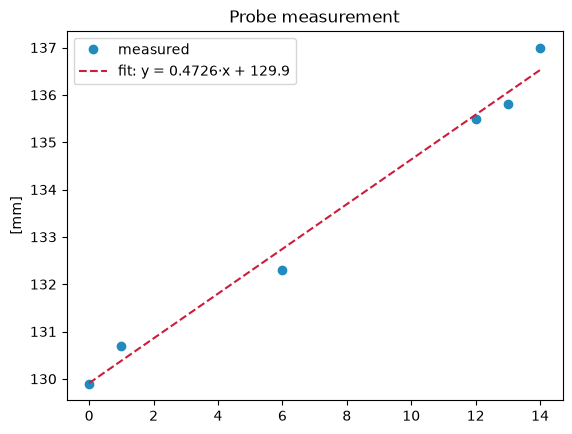

In [44]:
# Paired data with a linear fit overlaid in one call.
x := [0, 1, 6, 12, 13, 14]
y := [129.9, 130.7, 132.3, 135.5, 135.8, 137.0] mm
plot(x, y, ("measured", "o"), fit=1, title="Probe measurement")

`fit=N` fits a degree-`N` polynomial to the first paired-data series and overlays it (`fit=1` linear, `fit=2` quadratic). For the coefficients themselves use `linefit(x, y)` or `polyfit(x, y, deg)` — both are unit-aware and return the slope/intercept as dimensioned quantities.

**Themes.** Pass `theme=` to restyle a single plot. It is applied through a matplotlib style *context*, so it affects only that plot — it does not poison later plots in the session. Short aliases map to matplotlib's built-in styles (no `seaborn` package needed):

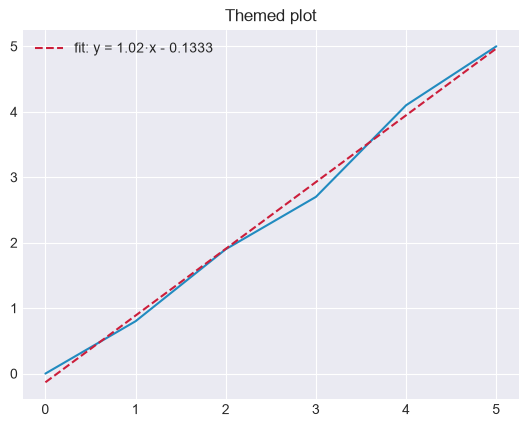

In [45]:
x := [0, 1, 2, 3, 4, 5]
y := [0.0, 0.8, 1.9, 2.7, 4.1, 5.0]
plot(x, y, fit=1, theme="darkgrid", title="Themed plot")

# list_themes() prints every short alias and every matplotlib style.
# Common aliases: dark, darkgrid, whitegrid, ggplot, 538, solarized,
# paper, presentation, colorblind.

**Axis labels follow the data.** Units on a series propagate to the axis label automatically — a `y` in `mm` gives a `[mm]` y-axis. Two `▸` idioms refine this:

* `plot(x, y ▸ μm)` — display that axis in a chosen unit.
* `plot(expr, t ▸ ms, (0, 5))` — on a *symbolic* sweep variable, `t ▸ ms` does not convert anything; it just labels the axis `t [ms]`. The sweep range is used verbatim.
* `plot(x ▸ "element", y)` — a bare string labels an axis that has no physical unit (a count, an index).

**Axes options.** `logx=`, `logy=` or `loglog=True` for logarithmic axes, `grid=True` (minor lines too on a log axis), `xlim=`/`ylim=` (unit-carrying ends are fine: `xlim=(1 Hz, 100 kHz)`), `figsize=(w, h)` and `save="file.png"`.

**Error bars.** A series of `±` values plots as points with error bars: `plot(x, [1.0 ± 0.1, 2.1 ± 0.2, …] V)`. The half-widths are drawn on the same display scale as the centres.

**Bode plots.** `bode(H, p, (f_min, f_max))` draws magnitude in dB and phase in degrees on twin panels over a logarithmic frequency axis. `H` is a sympy expression in the Laplace variable `p` (`s` is the second, so pick another letter), which is replaced by `j·2π·f`; `s=False` sweeps `p` itself as ω for an expression written with an explicit `i·ω`.

`plot()` returns `None` by default (so a notebook cell does not echo a matplotlib object); pass `return_ax=True` if you want the `Axes` for further customisation.

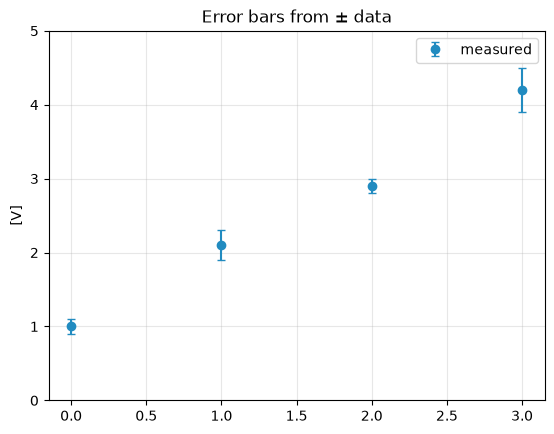

In [46]:
x := [0, 1, 2, 3]
y := [1.0 ± 0.1, 2.1 ± 0.2, 2.9 ± 0.1, 4.2 ± 0.3] V
plot(x, y, "measured", grid=True, ylim=(0 V, 5 V), title="Error bars from ± data")


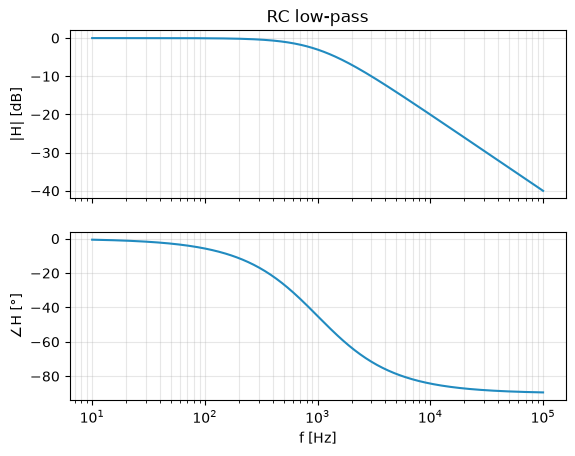

In [47]:
symbols: p
H_lp := 1/(1 + p/(2π·1000))              # first-order low-pass, f_c = 1 kHz
bode(H_lp, p, (10 Hz, 100 kHz), title="RC low-pass")


## 16. Integer bases

Two separate concerns, deliberately kept apart:

**Input — based literals.** Write an integer in any base 2–36 with a subscript-base suffix. This is parse-time lexing; the result is an ordinary `int` with no memory of how it was written (exactly like Python's own `0x1A`).

In [48]:
print(1010₂)              # binary  -> 10
print(17₈)                # octal   -> 15
print(1A₁₆)               # hex     -> 26
print(100₃₆)              # base-36 -> 1296

# Note: a based literal must start with a DIGIT. A letter-led token
# such as FF₁₆ would be read as an identifier with a subscript, so
# write it as 0FF₁₆ — or use the radix() function form for output.

10
15
26
1296


**Output — the `▸` radix tag.** `value ▸ hex` (or `▸ bin`, `▸ oct`, `▸ dec`) tags an integer for display in that base, using the same subscript notation as the input literals — so `1A₁₆` in, `1A₁₆` out. Like every `▸`, it is inert under arithmetic.

In [49]:
value := 0xF0
pv(value ▸ hex)        # F0₁₆
pv(value ▸ bin)        # 11110000₂

# Inert under arithmetic — the tag is consumed by the computation:
tagged := 255 ▸ hex
print(tagged + 1)         # plain 256, not a hex-tagged value
print((255 + 1) ▸ hex)    # tag the RESULT instead -> 100₁₆

# Function form: radix(value, base) takes any base 2..36 directly.
print(radix(100, 12))     # 84₁₂

<IPython.core.display.Math object>

<IPython.core.display.Math object>

256
100₁₆
84₁₂


**Custom formats — the registry.** `register_radix(name, fn)` adds a new integer notation, where `fn` is any `int → str` function. The toolkit ships a Roman-numeral format registered this way (in `radix_formats.py`):

In [50]:
print(2024 ▸ roman)       # MMXXIV
print(to_roman(1994))     # MCMXCIV  — the formatter is callable too

MMXXIV
MCMXCIV


**Roman numerals the other way — `"…"ᵣₒₘₑ` reads them in.** `▸ roman` is *display*: it formats an integer **out** as Roman numerals. The subscript literal `"…"ᵣₒₘₑ` is its inverse — it parses a Roman string **in**, to a plain `int`. The two are a matched pair, like `"…"ₜᵢₘₑ` (date in) has no display partner only because dates already print cleanly. Note the names differ by design: the subscript reads `ᵣₒₘₑ` (the spellable-in-Unicode-subscript approximation of “rome”) and the display tag reads `roman` — *input* and *output* are deliberately distinct words.

Between the two boundaries the value is just an integer, so ordinary integer machinery — ranges, arithmetic, loops — works unchanged. A range over two `ᵣₒₘₑ` literals is an integer range; re-applying `▸ roman` on the way out renders each step:

In [51]:
# "…"ᵣₒₘₑ  parses Roman → int;  ▸ roman  formats int → Roman.
# In between, anno is a plain integer (1909, 1910, …).
for anno in "MCMIX"ᵣₒₘₑ .. "MCMXII"ᵣₒₘₑ:
    pp(anno ▸ roman)

# Additive forms parse too — IIII is the traditional clock-face four:
print("IIII"ᵣₒₘₑ, "+", "IV"ᵣₒₘₑ, "=", "IIII"ᵣₒₘₑ + "IV"ᵣₒₘₑ)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

4 + 4 = 8


To add your own format, call `register_radix(name, fn)` with any `int → str` function. One timing subtlety: the `▸ name` *operator* resolves the name at source-rewrite time, so a format registered earlier in the **same cell** is not yet visible to `▸`. Register it in one cell, then use `▸ name` in a later cell — or use the `radix()` function form, which resolves at run time and needs no such ordering:

In [52]:
register_radix("underscored", lambda n: f"{n:_}")

# radix() form — resolves at run time, works immediately:
print(radix(1234567, "underscored"))   # 1_234_567

# The ▸ operator form works from the NEXT cell onward.

1_234_567


One guard worth knowing: using `and` / `or` next to a base-suffixed literal raises a deliberate `SyntaxError`. Python's logical operators return an *operand* — `26 and 71` is simply `71` — which silently masquerades as a bitwise result when the operands are bit patterns. Write `&` / `|` for bitwise logic; the error message spells out the fix when it fires.

## 17. Sets

The `| … |` bars are overloaded the way mathematics overloads them: **absolute value** for a number, **cardinality** for a set or any sized collection. The toolkit decides at runtime from the operand.

In [53]:
print(|{1, 2, 3}|)        # set cardinality -> 3
print(|{1, 2, 2, 3}|)     # set dedups      -> 3
print(|[1, 1, 2]|)        # list keeps dups -> 3
print(|-7|)               # number          -> 7  (abs, unchanged)

3
3
3
7


The empty set is written `∅` (the DSL normalises it to `set()`), and it *displays* as `∅` too — both as a bare cell result and through `pp`. For a plain-script context, `fmt(value)` returns the `∅`-aware string explicitly.

In [54]:
empty := ∅
pp(|empty|)            # 0
pp(empty)              # ∅
pp(fmt(set()))         # ∅  — explicit, for the print() path

<IPython.core.display.Math object>

∅
∅


## 18. ISO 286 limits and fits

`utils.iso286` brings the ISO 286-1 / 286-2 shaft-and-hole tolerancing system into the DSL. The design idea: a tolerance class such as `H7` or `g6` names a *band* of allowable sizes, and the toolkit already has the right primitive for a band — `Range`. So `hole()` and `shaft()` return `Range` intervals of millimetre `Physical`s, and everything else (interval arithmetic, `▸`, `.center`/`.tol`) just works.

In [55]:
bore := hole(25, "H7")          # Range: 25.000 .. 25.021 mm
pin  := shaft(25, "g6")         # Range: 24.993 .. 25.000 mm
print("hole :", bore)
print("shaft:", pin)

# A hole minus a shaft IS the clearance — interval arithmetic:
print("clearance:", bore - pin)

hole : (25 mm ‥ 25.0209180038045 mm)
shaft: (24.9796409558816 mm ‥ 24.9927147082594 mm)
clearance: (7.28529174059966 μm ‥ 41.2770479228733 μm)


`fit(nominal, hole_class, shaft_class)` analyses the pairing and classifies it as a **clearance**, **transition**, or **interference** fit, with the clearance extremes:

In [56]:
f := fit(25, "H7", "g6")
print("kind          :", f.kind)
print("min clearance :", f.min_clearance)
print("max clearance :", f.max_clearance)

kind          : clearance
min clearance : 7.28529174059966 μm
max clearance : 41.2770479228733 μm


Coverage: nominal sizes 1–500 mm, grades IT5–IT16, and the preferred-fit deviation letters `c d e f g h js k m n p r s`. `it_grade(d, grade)` and `tolerance_unit(d)` expose the underlying tolerance formulas directly.

*Accuracy note.* This module computes from the ISO 286-1 *formulas*; ISO 286-2 publishes *rounded* table values. Results can differ by ~1 µm at a rounding boundary — fine for fit selection, but cross-check a drawing callout against the printed table.

## 19. Currencies

Currencies are money, not physical units — their rates change daily — so they get their own `Currency` type rather than a `forallpeople` dimension. `DKK`, `USD`, `EUR`, `GBP`, `JPY`, `SEK`, `NOK`, `CHF`, `CAD`, `AUD`, `CNY`, `HKD`, `INR`, `PLN`, `CZK` are predefined; `▸` converts between them at the current rate. Rates come from Danmarks Nationalbank's public reference feed on first use, are cached on disk for 24 hours, and fall back to built-in approximations offline — `update_currency_rates()` forces a refresh, `rates_status()` reports the source and age.

Arithmetic is limited to what makes sense: scale by a number, add same-currency amounts, add cross-currency amounts (converted to the left side's currency). Multiplying two amounts raises, as does mixing money with a physical dimension. These are daily reference rates, not trading quotes.

In [57]:
salary := 50_000 USD
pv(salary ▸ DKK, salary ▸ EUR)      # at the current Nationalbanken rate
total := 100 USD + 200 DKK           # cross-currency add → LHS currency
pv(3 · salary, total)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

_S(3, _INF) * salary = 150,000.00 USD
total = 131.10 USD


## 20. Dates, times and durations

One polymorphic `iso(...)` handles ISO 8601 in both directions: strings parse into Python `date` / `datetime` / `time` / `timedelta` objects (`"P1Y6M"`, `"PT15M30S"` for durations; `'now'`, `'today'`, `'utcnow'` as keywords), and those objects format back into ISO strings. The subscript `ₜᵢₘₑ` on a string literal is the literal form — `"2026-05-05"ₜᵢₘₑ` is `iso("2026-05-05")`. Arithmetic is plain `datetime` semantics.

Durations with years or months are converted with fixed averages (365.25 days/year, 30.4375 days/month) — good for spans, not calendar-exact; for "same day next month" use `dateutil.relativedelta`. A duration that is a whole number of those years, months or weeks formats back the same way (`iso(iso("P1Y"))` is `"P1Y"`); anything else formats in days and time. Signed (`"-PT5M"`) and fractional (`"PT1.5H"`) durations parse. A `timedelta` reads in any time unit with `▸`: `"PT90M"ₜᵢₘₑ ▸ hour` is `1.5 hour`.

In [58]:
launch := "2026-05-05"ₜᵢₘₑ
review := launch + "P1M"ₜᵢₘₑ         # ≈ one month later (30.44 days)
pp(launch, review, iso(review))
pp(iso(iso("P1Y")), iso("-PT5M"), "PT90M"ₜᵢₘₑ ▸ hour)

2026-05-05 2026-06-04 2026-06-04
P1Y -1 day, 23:55:00


1.5 hour

## 21. Ranges and inequality loops

`[a..b]` is an *inclusive* numeric range. String endpoints sequence too — digits, single letters (incl. Greek), or a prefix with a numeric tail (`['C8'..'C13']`), preserving zero-padding — and ranges mix with single items in one list. Loop bounds can be written as a chained inequality — `for 1 ≤ k ≤ 5:` — with `<` and `≤` freely mixed, in comprehensions as well.

In [59]:
pp([1..5], ['C8'..'C11'])
squares := [k² for 1 ≤ k ≤ 5]
pv(squares)

[1, 2, 3, 4, 5]

['C8', 'C9', 'C10', 'C11']


<IPython.core.display.Math object>

## 22. Symbolic math

`symbols:` declares sympy symbols (ranges expand: `symbols: x..z, R1..R4`). Expressions built from them stay symbolic — `solve`, `.subs`, and the symbolic sweeps in the plotting section all apply — and the DSL notation (superscripts, `·`, subscript logs) works inside symbolic expressions.

**Equations.** A math-style `=` between symbolic operands builds a sympy `Eq`, so `solve(x² = 4, x)` and
`solve([x + y = 3, x − y = 1], [x, y])` read like the textbook. Between plain values `=` is still an
ordinary comparison returning a bool (`2 + 2 = 4` is `True`); the choice is made at run time by looking
at the operands.

**Calculus glyphs.** `∫(f, x)` is `integrate(f, x)` (`∫(f, (x, 0, 1))` for a definite integral) and
`∂(f, x)` is `diff(f, x)`. `∑` / `∏` remain the sum and product helpers.

**Subscripted symbol names.** `symbols: R₁, R₂` declares `R_1` and `R_2`, and — because the declaration
registers them — a later `R₁` in the session means that symbol rather than `R[1]`. Any name you have
*not* declared keeps the indexing meaning (`xs₁` is `xs[1]`).

Also at top level: `nsolve` (accepts DSL numbers as the starting guess), `lambdify`, `latex`, `nsimplify`,
`Matrix`, `det`, `eye`, `zeros`, `ones`, `diag`, and the sets `Reals`, `Integers`, `Naturals`. Everything
else in sympy is one `sym.` away.


In [60]:
symbols: x
expr := x² + 2·x + 1
pp(solve(expr, x), expr.subs(x, 3))
pp(solve(x² = 4, x), ∫(x², (x, 0, 1)), ∂(x³, x))
pp(nsolve(cos(x) − x, x, 1))
print(latex(x² + 1))
symbols: R₁, R₂
pp(solve(R₁ + R₂ = 10, R₁))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

x^{2} + 1


<IPython.core.display.Math object>

## 23. Matrices

A list-of-lists literal is a real (sympy) matrix with full linear algebra — product, powers (`M²`, `M⁻¹`), `.det()`, `.inv()`, eigenvalues — plus `ᵀ` for transpose and `|M|` for the determinant (the Euclidean norm when `M` is a row or column vector). 2-D element access uses the `͵` separator (U+0375): `M₀͵₁` is row 0, column 1. Matrices are 0-indexed like everything else in Python; negative indices count from the end, and out-of-range indices raise a clear error. Subscript assignment (`M₁͵₀ := 9`) mutates the matrix in place. Plain Python lists are untouched by all of this.

For vectors, `‖v‖` is the Euclidean norm and `norm`, `dot` and `cross` are unit-aware helpers that
accept plain lists, `[…] N` unit arrays and sympy column vectors alike: `dot([1, 2, 3] N, [4, 5, 6] m)`
is `32 J`. `‖` still reads as *parallel* between two operands (`R₁ ‖ R₂`); it is the norm only when
the opening bar starts an expression.

In [61]:
M := [[1, 2], [3, 4]]
pp(|M|, M⁻¹, M², Mᵀ, M₀͵₁)
M₁͵₀ := 9
pv(M)
F_vec := [3.0, 4.0] N
pp(‖F_vec‖, dot([1.0, 2.0, 3.0] N, [4.0, 5.0, 6.0] m), cross([1, 0, 0], [0, 1, 0]))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 24. Small conveniences

* `|x|` is `abs(x)` for numbers, the determinant for a matrix (norm for a vector) — and cardinality for sets and other sized collections. Binary `a | b` and `x |= y` are untouched.
* `∋` / `∌` read as *contains*: `A ∋ x` is `x in A`, container on the left as in mathematics.
* `⇥` and `↵` interleave a tab / newline as extra arguments in a call: `print(a ⇥ b ↵ c)`.
* `→` works as the return-type arrow in `def` and `lambda` signatures.
* `∧`, `∨`, `¬` are `and`, `or`, `not`; `∥` (U+2225) is accepted for `‖`; `∆` (U+2206) is read as `Δ`.
* `round(x, n)` works on any DSL value and keeps its unit (`round(1.2345 V, 2)` → `1.23 V`; rounding is on the SI magnitude); `math.floor/ceil/trunc` and `divmod` work too.
* `hypot(a, b, …)`, `cbrt(x)`, `sign(x)`, `clamp(x, lo, hi)` are unit-aware; `gcd`, `lcm`, `comb`, `perm` come from `math`; `nan` joins `∞`.

In [62]:
primes := {2, 3, 5, 7}
pp(|-5|, |primes|, primes ∋ 5, primes ∌ 9)

def halved(x) → float:
    return x / 2

print("a" ⇥ "b" ↵ "c", halved(9))
print(True ∧ ¬False, comb(5, 2))
pp(round(1.2345 V, 2), hypot(3.0 m, 4.0 m), clamp(5 V, 0 V, 3.3 V))

5

4 True True
a 	 b 
 c 4.5
True 10


<IPython.core.display.Math object>

## 25. The wider unit catalogue

`utils.extra_units` fills in what the SI default environment doesn't carry. Every name is an ordinary `forallpeople.Physical`, so all of them scale by numbers, mix with SI, and re-express with `▸`; conversions are exact wherever the official definition is exact. The families:

* **Imperial / practical** — `inch`, `ft`, `yard`, `mile`, `mil`, `thou`; `lb`, `oz`, `stone`, `tonne`, `ton_us`/`ton_uk`; `lbf`, `kgf`, `dyne`; `gal_us`/`gal_uk`, `pt_us`, `fl_oz_us`, `litre`/`liter`, `cc`, `barrel`; `mph`, `kph`, `knot`, `nautical_mile`; `BTU`, `cal`/`Cal`/`kcal`, `kWh`, `hp` (plus `hp_metric`, `hp_electrical`).
* **Pressure** — `Pa` with prefixes, `bar`/`mbar`, `atm`, `mmHg`, `torr`, `psi`/`ksi`, `inH2O`.
* **Torque (display-preserving)** — `Nm`, `Nmm`, `mNm`, `kNm`, `MNm`, `lbf_ft`, `lbf_inch`, `ozf_inch`. Torque shares its dimension with energy, so these carry a display tag: `25 Nm` stays `N·m`, never `J`.
* **Particle physics** — `eV` through `EeV`; masses as `eV_per_c2`…`TeV_per_c2`, momenta as `eV_per_c`…; cross sections `barn` down to `abarn`; `amu`/`Da`/`u`; `erg`; `Å`; `fm`, `fs`, `ps`, `ns`.
* **Astronomy** — `au`, `ly`, `pc`/`kpc`/`Mpc`/`Gpc`; `yr`/`kyr`/`Myr`/`Gyr` (Julian year); flux density `Jy`/`mJy`/`μJy`; and the Sun/Earth/Jupiter reference values `M_sun`, `R_sun`, `L_sun`, `T_sun`, `M_earth`, `R_earth`, `M_jupiter`, `R_jupiter`, `M_moon` (IAU 2015 nominal values).

* **Electrical** — conductance `siemens`/`mho`, `mS`, `μS`, `kS`; charge capacity `Ah`, `mAh`, `kAh`; apparent and reactive power `VA`/`kVA`/`MVA` and `var`/`kvar`/`Mvar` (display-tagged, like torque); magnetic `mT`, `μT`, `nT`, `gauss`/`Gs`; energy `mJ`…`pJ`, `mWh`, `MWh`, `GWh`.
* **Mechanical / process** — `L`, `kL`, `cL`, `μL`; `ha`, `are`, `acre`; `mmol`, `μmol`, `kmol`; viscosity `Pa_s`, `poise`, `cP`, `St`, `cSt`; `kip`; `mPa`, `μPa`; aliases `yd`, `nmi`, `dyn`.
* **Photometry / radiation** — `lm`, `lx`, `klx`; `Bq`, `kBq`, `MBq`, `Ci`; `Sv`, `mSv`, `μSv` (all display-tagged so `1/s` does not print as Hz).
* **Time and angle** — `minute`, `hour`/`hr`, `day`, `week`, `month`, `year`; `rad`, `sr`, `deg`, `mrad`, `arcmin`, `arcsec`, `rev`, `gon` (dimensionless numbers); `rpm`, `rps` (frequencies). Note that `h` is Planck's constant and `min` is Python's builtin, so `5 km/h` is *not* a speed: write `km/hr` (or `km/hour`) and `L/minute`. The transformer warns when it sees `<unit>/h` or `<unit>/min`.

The astronomy names also accept the journal glyphs: `M☉`, `R☉`, `L☉`, `T☉` (circled-dot variants `M⊙`, `R⊙`, `L⊙` too), `M⊕`/`R⊕` for Earth, and `M♃`/`R♃` for Jupiter — `2 · M☉` is exactly `2 * M_sun`. The full inventory is `dir(utils.extra_units)`. Every unit the module exports binds tightly to a preceding number automatically (`5 mAh / 2 hr` is `(5 mAh)/(2 hr)`), so a unit added there needs no other registration.

In [63]:
span := 5. inch + 2. cm
tire := 32. psi
τ_wrench := 25. Nm                    # torque keeps N·m, never J
pv(span ▸ inch, tire ▸ bar, τ_wrench)
cap := 2500 mAh
pp(cap · 3.7 V ▸ Wh, 230 V · 10 A ▸ kVA, 1/(20 Ω), 0.5 gauss ▸ μT, 500 lx)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [64]:
m_star := 2.1 M☉                      # journal glyph, same as M_sun
pv(m_star, m_star ▸ M_jupiter)
d_prox := 1.301 pc
pv(d_prox ▸ ly)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [65]:
E_beam := 6.8 TeV
m_prot := 938.3 MeV_per_c2            # particle masses in MeV/c²
pp(E_beam ▸ J, m_prot ▸ kg)

<IPython.core.display.Math object>

## 26. Limitations and gotchas

A list of things to watch for. Some are inherited from the libraries underneath; the later ones are consequences of the toolkit's own design choices, and are features rather than bugs once you know them.

**Units and display**

1. **Temperature units are offset-correct — mind absolute vs delta.** `°C`, `°F`, `°R` are real offset units: `22 °C` is stored as `295.15 K`. A bare literal displays on its own scale (`22 °C`); arithmetic results come back in SI (`20 °C + 5 ΔC` → `298.15 K`), and `▸ degC` / `▸ degF` / `▸ degR` re-express any temperature on another scale (`25 °C`, `71.6 °F`, …). The one thing to keep straight is **absolute vs delta**: `°C`/`°F`/`°R` are points on a scale (offset applied); `ΔC`/`ΔF`/`ΔK` are differences (no offset). `20 °C + 5 ΔC` = `298.15 K` (= 25 °C) is right; `100 °C - 20 °C` gives `80 ΔC`, a difference; but `20 °C + 5 °C` adds two scale points and is physical nonsense (~571 K) — the toolkit will not stop you. Compound units involving temperature (`J/K`, `W/(m·K)`, the gas constant) are rendered by `forallpeople` directly and are unaffected.

2. **Sub-yocto magnitudes have no SI prefix — handled, with a cosmetic cost.** `forallpeople`'s prefix table bottoms out at yocto (10⁻²⁴). A value smaller than that — `m_e` at 9.1 × 10⁻³¹ kg is the usual example — has no prefix to display in, and `forallpeople`'s rich-display hooks (`_repr_html_` / `_repr_latex_`) raise `KeyError: None`. `Sig` intercepts those hooks: when the wrapped value's rich repr fails, it declines cleanly and the value falls back to plain text (`9.1093837015e-31 kg`). So a bare `m_e` in a cell displays fine — you simply get the plain form rather than `forallpeople`'s formatted HTML. The moment the quantity reaches a representable magnitude (`m_e * c²` → fJ) the rich display returns. The math was never affected; only the rendering.

3. **Per-element auto-prefixing on arrays.** `forallpeople` chooses an SI prefix for *each* value independently. In an array like `[0 m, 700 µm, 2 mm]` each element prints in its own prefix, and a naive strip of the display magnitudes would put them on different scales. `plot()`, `linefit()` and `polyfit()` handle this correctly (they reduce a whole array to one common scale); but if you strip units from an array by hand, reduce to SI base first, not per-element `float()`.

4. **`h` is Planck's constant, `min` is a builtin.** `90 km/h` evaluates silently to nonsense (`kg⁻¹·m⁻¹·s`) and `20 L/min` is a `TypeError`. The transformer emits a `SyntaxWarning` for `<unit>/h` and `<unit>/min`; the time units are `hr`/`hour` and `minute`. (`J/h`, a frequency from an energy, is legitimate physics and still works — with the same warning.)

5. **Single-letter unit names get shadowed.** Writing `V := 5 V` rebinds `V` to 5 volts, so later uses of `V` no longer mean "volts". The same applies to `A`, `F`, `H`, `J`, `N`, `C`, `T`, `K`. Use longer variable names (`V_supply`) or restore the unit at the start of each cell.

5b. **A written unit survives multiplication by a plain number — including 2π.** The tag that keeps `25 Nm` printing as `N·m` also keeps `2π · 3000 rpm` printing in rpm, because nothing dimensional changed. Convert rotational speed explicitly: `ω := 2π · n ▸ "rad/s"` labels the result honestly, and `n ▸ Hz` / `f ▸ rpm` convert between the two frequencies.

**The `▸` display-preference operator**

6. **`▸` is consumed by arithmetic — by design.** A `▸`-tagged value is a *display preference*, not a new kind of number. Any arithmetic on it unwraps to the underlying dimensioned value and the tag does not survive — the unit does. This is what makes `(a ▸ mm/s) / (b ▸ mm/s)` correctly dimensionless and `(z ▸ mm) + (b ▸ mm)` a real length. Apply `▸` at the *edge* of an expression, on output.

7. **Do not put `▸` upstream of arithmetic you care about.** Because the conversion is applied when the tag is created, `(50 mm ▸ mm) / 2` yields a dimensionless `25`, not `25 mm` — the real unit was already reduced to a bare magnitude before the `/`. Write `(50 mm / 2) ▸ mm` instead. Consistent with rule 6, but easy to trip over.

**Significant figures**

8. **Subtraction can destroy significant figures — correctly.** Subtracting two near-equal values (`132. mm - 125. mm`) leaves a result known to far fewer figures than either input (`7. mm`, 1 sf). This is real loss-of-significance, not a toolkit bug. If a factor in the calculation is an *exact* reference rather than a measurement, wrap it in `exact(…)` so it does not cap precision.

**Symbolic / Python-level**

9. **`=` is equality, not assignment.** `R = 220 Ω` is a bool (or a sympy `Eq` when a side is symbolic). Use `:=` or `←` to assign. The rewrite is conservative — walrus (`(x := f()) > 0`) and keyword arguments (`f(rtol=1e-3)`) still work because their left side is not a bare assignable target.

10. **Subscripts are indexing, not naming.** `R₁ := 220 Ω` is `R[1] = …` — it tries to assign into a non-existent `R`. Use `R1` or `R_1` for variable names; reserve subscript glyphs for indexing. The one exception is a name declared with `symbols: R₁` — that registers `R₁` as the sympy symbol `R_1` for the rest of the session.

11. **`ℏ` is normalised to `ħ` internally.** Python 3 applies NFKC normalisation to identifiers, and U+210F normalises to U+0127. You can write `ℏ` everywhere — lookups are normalised too — but `dir(module)` shows `ħ`.

**Display of sets**

12. **`print()` shows `set()`, `pp()` shows `∅`.** An empty set displays as `∅` as a bare cell result and through `pp`/`pn`. But `print()` is the unmodified Python builtin — it calls `str()`, and `str(set())` is fixed as `'set()'`. Use `pp(x)`, or `print(fmt(x))` for the `∅` symbol in a `print` call.

**ISO 286**

13. **ISO 286 values are formula-derived.** `utils.iso286` computes from the ISO 286-1 *formulas*; ISO 286-2 publishes *rounded* table values. Results can differ by ~1 µm at a rounding boundary — fine for fit selection, but verify a drawing callout against the printed table.

## 27. Quick-reference card

### Glyphs and their meanings

| Glyph | Rewrites to | Notes |
|---|---|---|
| `:=`, `←` | `=` | math assignment |
| `=` | `_eq(_, _)` | equality — `bool`, or sympy `Eq` when symbolic (not walrus / kwarg) |
| `²`, `³` | `**2`, `**3` | postfix superscript |
| `√x`, `³√x`, `∛x`, `∜x` | `sqrt(x)`, `x**(1/3)`, … | prefix roots |
| `sin⁻¹(x)` … | `asin(x)` … | inverse trig / hyperbolic |
| `‖`, `∥` | `parallel(_, _)` | infix; chains of 3+ work |
| `‖v‖` | `norm(v)` | when the opening bar starts an expression |
| `±` | `plusminus(_, _)` | binary infix; result prints as `(low ‥ high)`; a `%`/`‰` tolerance is relative |
| `‥` | `_interval(_, _)` | closed interval from its ends — the `±` printout, pasteable |
| `[a..b]`, `a..b` | `_range_inc(a, b)` | inclusive enumeration; ends may carry units |
| `≈` | `approx(_, _)` | comparison precedence: `1 + 1 ≈ 2` compares the sum |
| `∠` | `phasor(_, _)` | binary infix; runs after `°` |
| `▸` | `in_units(_, _)` / `radix(_, _)` | display preference — see below |
| `°` | `*(π/180)` | postfix angle (not before `C`) |
| `°C`, `℃` | `degC` | normalised early |
| `⌊x⌋`, `⌈x⌉`, `\|x\|` | `floor`, `ceil`, `abs`-or-`len` | see note |
| `x₁`, `x₂` … | `x[1]`, `x[2]` | subscript indexing (NOT naming) |
| `log₁₀(x)`, `log₂(x)` | `log10(x)`, `log2(x)` | subscript base |
| `1A₁₆`, `1010₂`, `17₈` | based integer literal | any base 2–36 |
| `25%`, `5‰` | `percent(25)`, `permille(5)` | postfix |
| `n!` | `fact(n)` | postfix |
| `·`, `⋅`, `×` | `*` | normalised early |
| `÷` | `/` | normalised early |
| `≠`, `≤`, `≥` | `!=`, `<=`, `>=` | normalised early |
| `½`, `⅓`, `¼` … | `(1/2)`, `(1/3)`, `(1/4)` | precomposed fractions |
| `∞` | `inf` | rewrites to identifier |
| `∧`, `∨`, `¬` | `and`, `or`, `not` | logic |
| `∫(f, x)`, `∂(f, x)` | `integrate`, `diff` | calculus |
| `∅` | `set()` | empty set; also displays as `∅` |
| `∋`, `∌` | `in` / `not in` (operands swapped) | contains — container on the left |
| `Mᵀ`, `M²`, `M⁻¹` | `M.T`, `M**2`, `M**-1` | matrix transpose, power, inverse |
| `M₀͵₁` | 2-D matrix indexing | 0-based; `͵` is U+0375 |
| `"…"ₜᵢₘₑ` | `iso("…")` | ISO 8601 date/time/duration literal |
| `⇥`, `↵` | `, "\t",` / `, "\n",` | interleave tab/newline in a call |
| `→` | `->` | return-type arrow in `def`/`lambda` |

`\|x\|` dispatches on the operand: **absolute value** for a number, **determinant** for a matrix (norm for a vector), **cardinality / length** for a set or sized collection.

### The `▸` operator (display preference)

`value ▸ target` tags a value for display. **Inert under arithmetic** — the tag is consumed by any computation, so apply it on output.

| Form | Effect |
|---|---|
| `x ▸ mm` | display `x` in that unit |
| `x ▸ hex` / `bin` / `oct` / `dec` | display integer in that base |
| `x ▸ roman` | display integer via a registered custom format |
| `θ ▸ deg` | angle in degrees (`rad` = 1) |
| `R ▸ plusminus`, `R ▸ percent`, `R ▸ permille` | interval as centre ± tolerance |
| `z ▸ polar`, `z ▸ rect` | complex in polar / rectangular form |
| `td ▸ hour` | a `timedelta` in a time unit |
| `x ▸ "label"` | a bare string label (axis with no physical unit) |
| `amount ▸ EUR` | convert a `Currency` amount at the current rate |
| `plot(expr, t ▸ ms, …)` | label a symbolic plot axis (no conversion) |

### Runtime helpers

| Name | What it does |
|---|---|
| `Γ(x)` | `math.gamma` with sf preservation |
| `Π(iter)` | product, sf min-rule |
| `Σ(iter)` | sum |
| `σ(iter, ddof=0)` | std deviation — unit-aware |
| `log10`, `log2`, `ln` | logs with sf preservation |
| `sin` … `atanh`, `exp` | numeric with sf preservation; exact on exact angles; symbolic on symbols; error on a dimensioned argument |
| `atan2(y, x)` | unit-aware — both legs must share a dimension |
| `hypot(a, b, …)`, `cbrt`, `sign`, `clamp` | unit-aware helpers |
| `norm`, `dot`, `cross` | unit-aware vector helpers (lists, `[…] N` arrays, sympy vectors) |
| `gcd`, `lcm`, `comb`, `perm`, `nan` | from `math` |
| `round(x, n)` | works on Sig / units; `math.floor`, `ceil`, `trunc`, `divmod` too |
| `floor`, `ceil` | sf preservation |
| `phasor(mag, ang)` | polar → complex; mag and ang must be unitless (a unit raises) |
| `to_dB_v`, `to_dB_p` | 20·log₁₀ / 10·log₁₀ |
| `from_dB_v`, `from_dB_p` | inverse |
| `approx(a, b, rtol, atol, sf=False)` | tolerant equality; `sf=True` compares to the stated precision |
| `interp(x, xs, ys)` | unit-aware table lookup (linear; `extrapolate=True` continues the ends) |
| `polar(z)`, `rect(z)` | complex display form |
| `parallel(a, b)` | `1/(1/a + 1/b)` |
| `percent(x)`, `permille(x)` | `x/100`, `x/1000` |
| `fact(x)` | factorial |
| `exact(x)` | mark a value as exact (sf = ∞) |
| `measured(x, sf)` | mark a value with an explicit sf |
| `Range.from_pm(c, δ)` | `[c-δ, c+δ]`; `x in R`, `abs(R)`, `.center`, `.tol`, `.width`, functions of an interval |
| `radix(value, base)` | integer in any base 2–36 |
| `register_radix(name, fn)` | add a custom integer format |
| `to_roman(n)` | integer → Roman numeral string |
| `nsolve`, `lambdify`, `latex`, `det`, `eye`, `zeros`, `diag` | sympy, at top level |
| `pp(a, b, …)` | pretty-print values (LaTeX in a notebook) |
| `pv(x, …)` | print `name = value`; bare `pv()` dumps every variable |
| `fmt(value)` | string form, empty set as `∅` |
| `iso(x)` | ISO 8601 parse/format, both directions |
| `update_currency_rates()` | refresh rates from Nationalbanken |
| `rates_status()` | currency-rate source and age |

### Plotting

| Name | What it does |
|---|---|
| `plot(…)` | unit/symbolic-aware matplotlib wrapper |
| `plot(…, fit=N)` | overlay a degree-`N` polynomial fit |
| `plot(…, theme="…")` | per-plot style (local, non-poisoning) |
| `linefit(x, y)` | unit-aware linear fit — slope, intercept |
| `polyfit(x, y, deg)` | unit-aware polynomial fit |
| `plot(…, logx=, logy=, loglog=, grid=, xlim=, ylim=, figsize=, save=)` | axes options |
| `plot(x, [a ± δ, …])` | error bars from interval data |
| `bode(H, p, (f_min, f_max))` | magnitude / phase panels over log frequency |
| `list_themes()` | print available plot themes |

### ISO 286 limits and fits (`utils.iso286`)

| Name | What it does |
|---|---|
| `hole(nominal, "H7")` | hole tolerance band as a `Range` of mm |
| `shaft(nominal, "g6")` | shaft tolerance band as a `Range` of mm |
| `fit(nominal, hole, shaft)` | clearance/transition/interference analysis |
| `it_grade(d, grade)` | IT-grade band width |
| `tolerance_unit(d)` | the standard tolerance unit `i` |

### Constants and unit families (from `utils.calc_symbols`, `utils.extra_units`)

| Group | Members |
|---|---|
| Defined-exact SI | `c`, `h`, `ℏ`, `k_B`, `N_A`, `q_e`, `g_n`, `T_0`, `R_gas` |
| CODATA-measured | `ε_0`, `μ_0`, `m_e`, `m_p`, `m_n`, `G`, `σ_SB`, `α_fs`, `a_0`, `μ_B`, `Z_0`, `R_∞`, `b_wien` |
| Derived / conventional | `Faraday`, `p_0` |
| Prefix-bearing units | `pA`…`A`, `Ω`…`MΩ`, `pF`…`μF`, `Hz`…`MHz`, `pm`…`cm`, `ms`… |
| Particle / nuclear | `eV`…`EeV`, masses `MeV_per_c2`…, `barn`…`abarn`, `amu`/`Da`, `erg`, `Å` |
| Astronomical | `au`, `ly`, `pc`/`kpc`/`Mpc`, `Jy`, `yr`/`Myr`/`Gyr`, `M☉`, `R⊕`, `M♃`, `L☉`, `T☉` |
| Imperial / practical | `inch`, `ft`, `yd`, `mile`, `nmi`, `lb`, `kip`, `psi`, `bar`, `atm`, `gal_us`, `L`, `kWh`, `MWh`, `hp`, `knot` |
| Electrical / magnetic | `mS`, `Ah`, `mAh`, `VA`, `var`, `mT`, `gauss` |
| Angle / rotation | `rad`, `deg`, `mrad`, `arcmin`, `rev`, `gon`, `rpm`, `rps` |
| Light / radiation / process | `lm`, `lx`, `Bq`, `Sv`, `cP`, `cSt`, `ha`, `mmol` |
| Other | `π`, `degC`, `i` (= `1j`), `inf` / `∞` |

*Constant and unit names above are indicative; `from utils.Engineer import *` brings the full set into scope. The particle-physics and astronomical families are the additions most likely to be unfamiliar — they follow the same `value * unit` pattern as the SI base units.*